In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.linalg import eigh as sp_eigh
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from mlxtend.plotting import plot_decision_regions

In [2]:
class LDA:
    def __init__(self, n_components=None):
        self.n_components = n_components

    def fit(self, X, y):
        n_samples, n_features = X.shape
        classes, cls_counts = np.unique(y, return_counts=True)
        priors = cls_counts / n_samples

        X_cls_mean = np.array([X[y == cls].mean(axis=0) for cls in classes])
        between_cls_deviation = X_cls_mean - X.mean(axis=0)
        within_cls_deviation = X - X_cls_mean[y]

        Sb = priors * between_cls_deviation.T @ between_cls_deviation
        Sw = within_cls_deviation.T @ within_cls_deviation / n_samples
        evals, evecs = sp_eigh(Sb, Sw)
        self.dvecs = evecs[:, np.argsort(evals)[::-1]]   # discriminant vectors

        self.weights = X_cls_mean @ self.dvecs @ self.dvecs.T
        self.bias = np.log(priors) - 0.5 * np.diag(X_cls_mean @ self.weights.T)

        if self.n_components is None:
            self.n_components = min(classes.size - 1, n_features)

    def transform(self, X):
        return X @ self.dvecs[:, : self.n_components]

    def predict(self, X_test):
        scores = X_test @ self.weights.T + self.bias

        return np.argmax(scores, axis=1)

In [3]:
star_type = pd.read_csv('Stars.csv')
print(star_type.head())

X, y = star_type.iloc[:, :-1], star_type.iloc[:, -1]

cat_features_list = X.select_dtypes(include=['object']).columns
X[cat_features_list] = X[cat_features_list].apply(LabelEncoder().fit_transform)

X, y = X.values, LabelEncoder().fit_transform(y)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

   Temperature         L       R    A_M Color Spectral_Class  Type
0         3068  0.002400  0.1700  16.12   Red              M     0
1         3042  0.000500  0.1542  16.60   Red              M     0
2         2600  0.000300  0.1020  18.70   Red              M     0
3         2800  0.000200  0.1600  16.65   Red              M     0
4         1939  0.000138  0.1030  20.06   Red              M     0


In [5]:
lda = LDA()
lda.fit(X_train, y_train)
y_pred = lda.predict(X_test)
transformed = lda.transform(X_train)
lda_accuracy = accuracy_score(y_test, y_pred)

print(f'LDA accuracy: {lda_accuracy}')
print(f'prediction: {y_pred}')
print('Transformed features', transformed[:5].T, sep='\n')

LDA accuracy: 1.0
prediction: [2 0 3 4 4 5 5 2 0 2 4 2 5 4 5 5 0 1 3 0 0 1 5 3 5 3 1 2 5 3 3 4 2 0 1 0 1
 5 1 5 4 5 4 1 3 0 4 3]
Transformed features
[[ 7.87705156  8.95198724  6.88034418  9.63640061  6.38600123]
 [ 3.81283152  4.37883318  3.11739228  4.74662633  2.75308976]
 [ 2.53283917  2.56815124 -0.89243729  2.61377932 -1.34975314]
 [-2.57526866 -2.42449806 -0.50609565 -2.31364867 -0.85504012]
 [ 3.56156777  3.6819747   2.95100861  3.73170035  3.40834168]]


ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 6 is different from 2)

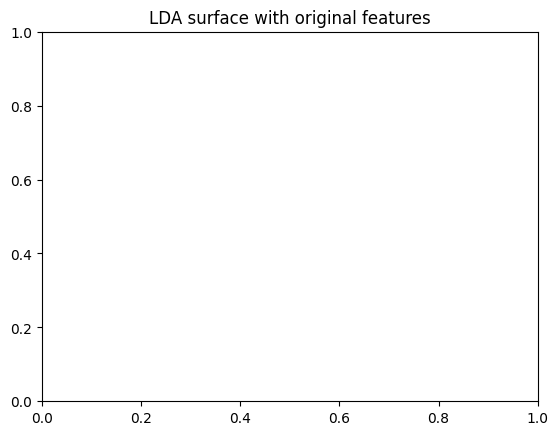

In [6]:
feature_indexes = [3, 0]

plt.title('LDA surface with original features')
plot_decision_regions(X=X[:, feature_indexes], y=y, clf=lda)